# Stacking Regression

## Import Required Libraries

In [1]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

## Load Engineered Features

In [2]:
df = pd.read_csv('../feature_engineering.csv')

In [3]:
feature_columns = [
    'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words', 'sentence_count', 'syllables_per_word',
    'polysyllable_count', 'flesch_reading_ease', 'automated_readability_index',
    'dale_chall_readability_score', 'difficult_words', 'linsear_write_formula',
    'spache_readability', 'reading_time'
]

X = df[feature_columns]
y = df['fk_estimated_uk_age_num']

## Model Training and Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=456
)

## Hyperparameter Tuning

In [5]:
base_learners = [
    ('lr', LinearRegression()),
    ('ridge', Ridge(alpha=np.float64(0.11), max_iter=20000, random_state=4)),
    ('rf', RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=1, 
                                 min_samples_split=5, n_estimators=100, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=1000, max_depth=7, learning_rate=0.1, subsample=0.7, 
                         colsample_bytree=0.8, random_state=456, n_jobs=-1))
]

# Meta-learner: use a simple linear regression
meta_learner = LinearRegression()

# Stacking regressor
stacking_reg = StackingRegressor(estimators=base_learners, final_estimator=meta_learner, cv=5)

# Train the stacking regressor
stacking_reg.fit(X_train, y_train)



,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('lr', ...), ('ridge', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",LinearRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[LinearRegression(), Ridge(alpha=n...andom_state=4), RandomForestR...ndom_state=42), XGBRegressor(...ree=None, ...)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U28](14,)","['word_count','average_word_length','percent_complex_words',..., 'linsear_write_formula','spache_readability','reading_time']"
final_estimator_ final_estimator_: estimatorThe regressor fit on the output of `estimators_` and responsible forfinal predictions.,LinearRegression,LinearRegression()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,14


## Save the Trained Model

In [6]:
joblib.dump(stacking_reg, '../../models/stacking_regressor.joblib')

['../../models/stacking_regressor.joblib']

## Evaluate Results

In [7]:
y_pred = stacking_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print(f"R^2 Score: {r2:.2f}")

y_train_pred = stacking_reg.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Train MAE: {mae_train:.2f}, Train R^2: {r2_train:.2f}")
print(f"Test MAE: {mae:.2f}, Test R^2: {r2:.2f}")

MAE: 0.25101769915087446
MSE: 0.08646396423529222
RMSE: 0.29404755437733576
R^2 Score: 1.00
Train MAE: 0.24, Train R^2: 1.00
Test MAE: 0.25, Test R^2: 1.00


In [8]:
results = {
    'Model': 'Stacking Regressor',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2,
    'Params': str(stacking_reg.get_params()),
    'Notes': ''
}

In [9]:
results_file = '../all_model_results.csv'

# Turn the results dict into a DataFrame row
df_result = pd.DataFrame([results])

# If file exists, append without headers; else, create with headers
if os.path.isfile(results_file):
    df_result.to_csv(results_file, mode='a', header=False, index=False)
else:
    df_result.to_csv(results_file, index=False)

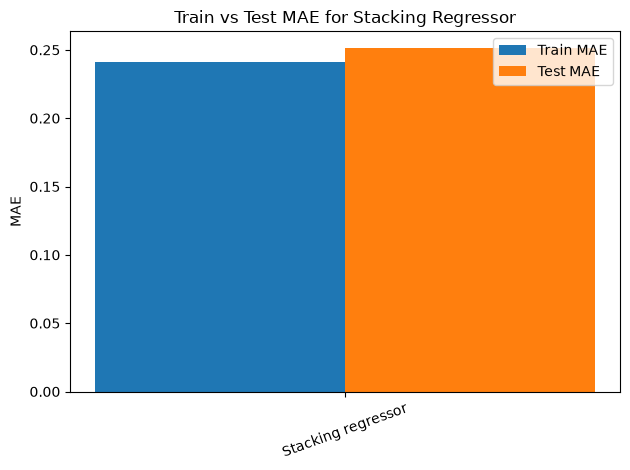

In [10]:
import matplotlib.pyplot as plt

# Visualize train vs test MAE for the Stacking model

models = ['Stacking regressor']
train_mae = [mae_train]
test_mae = [mae]

x = range(len(models))
plt.bar(x, train_mae, width=0.4, label='Train MAE')
plt.bar([i + 0.4 for i in x], test_mae, width=0.4, label='Test MAE')

plt.xticks([i + 0.2 for i in x], models, rotation=20)
plt.ylabel('MAE')
plt.title('Train vs Test MAE for Stacking Regressor')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance Visualisation

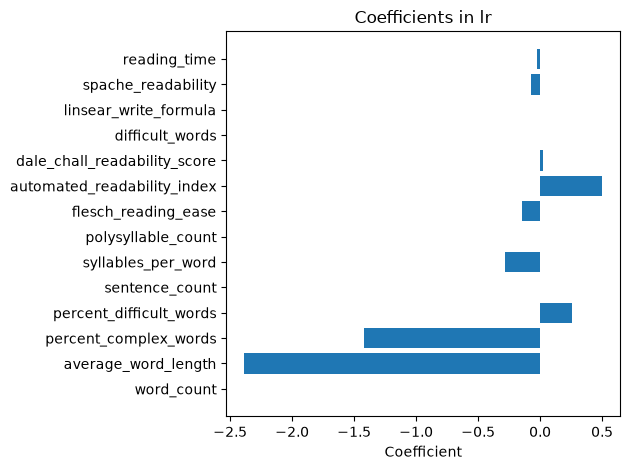

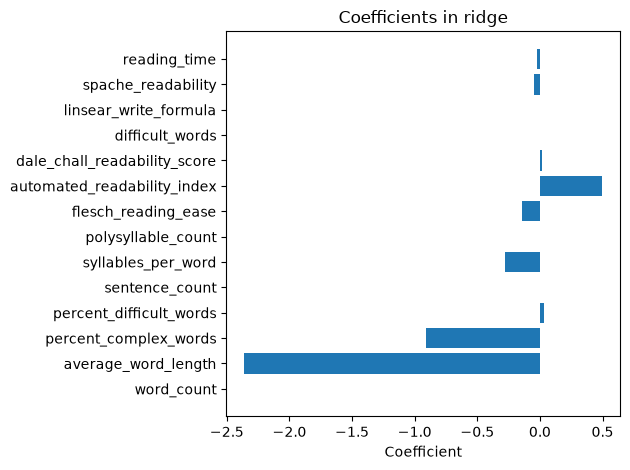

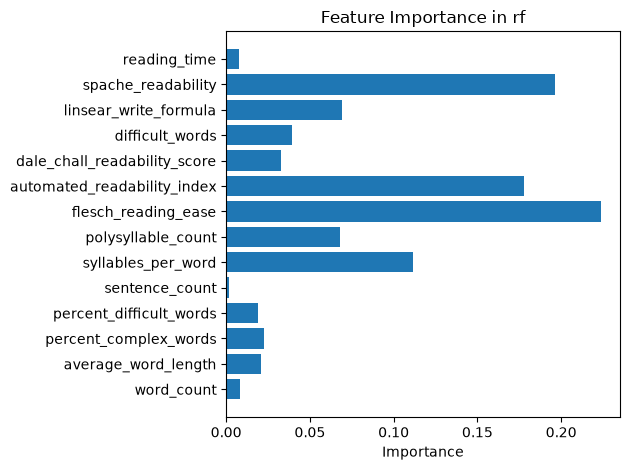

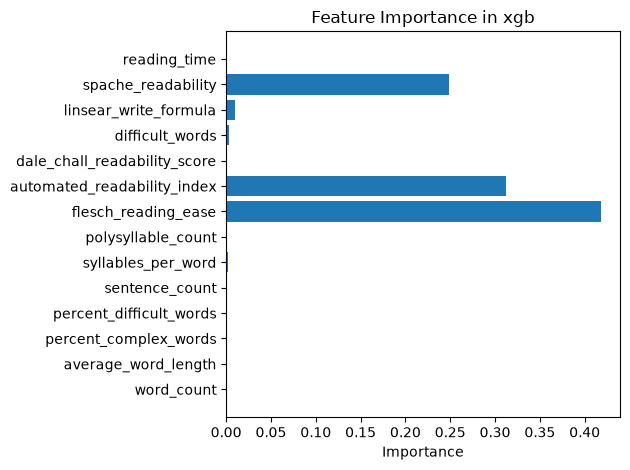

In [11]:
for name, model in stacking_reg.named_estimators_.items():
    plt.figure()
    if hasattr(model, "feature_importances_"):
        plt.barh(feature_columns, model.feature_importances_)
        plt.xlabel("Importance")
        plt.title(f"Feature Importance in {name}")
    elif hasattr(model, "coef_"):
        plt.barh(feature_columns, model.coef_)
        plt.xlabel("Coefficient")
        plt.title(f"Coefficients in {name}")
    else:
        plt.text(0.5, 0.5, f"No importances or coefficients for {name}", ha='center')
        plt.title(f"{name} (No importances or coefficients)")
    plt.tight_layout()
    plt.show()

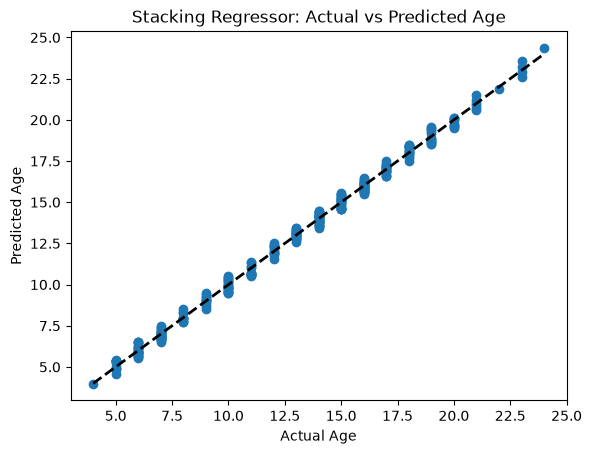

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Stacking Regressor: Actual vs Predicted Age")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()